# DADA2 quickstart via **`pydada2`** (single-end)

A minimal end-to-end DADA2 walk-through on the canonical
``sam1F.fastq.gz`` fixture that ships with the upstream R DADA2
package. Demonstrates dereplication → ASV inference → cluster
inspection — the same workflow as
`https://benjjneb.github.io/dada2/tutorial.html`, in pure Python.

This notebook drives `from pydada2 import ...` directly — no R, no
rpy2, no Bioconductor. The DADA2 algorithm (divisive amplicon
denoising with Poisson abundance p-values, kmer pre-screen, banded
Needleman-Wunsch endsfree alignment) is reimplemented in NumPy +
Numba and bit-exact reproduces R DADA2's ASVs on this fixture
(see ``tests/test_r_parity.py``).


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt

import pydada2
from pydada2 import derep_fastq, dada

EXTDATA = '/scratch/users/steorra/analysis/omicverse_dev/cache/dada2_src/inst/extdata'
print('pydada2 version:', pydada2.__version__)

pydada2 version: 0.1.0


## 1. Dereplicate the FASTQ

Identical reads are collapsed into "uniques", carrying their
abundance and per-position rounded-mean quality. This is the input
representation the DADA2 inference algorithm consumes.

In [2]:
drp = derep_fastq(f'{EXTDATA}/sam1F.fastq.gz', verbose=True)
print(f'unique sequences: {drp.n_unique}')
print(f'total reads:      {int(drp.abundances().sum())}')
print(f'most abundant:    {drp.abundances()[0]} reads')

Dereplicating sequence entries in /scratch/users/steorra/analysis/omicverse_dev/cache/dada2_src/inst/extdata/sam1F.fastq.gz…
  Encountered 1500 total sequences in 896 unique sequences.
unique sequences: 896
total reads:      1500
most abundant:    205 reads


## 2. Define the error model

For quickstart we use a flat error matrix (1 % per substitution at
all quality scores). In production you would learn this from the
data via `pydada2.learn_errors(...)`, which mirrors R DADA2's
`learnErrors` — alternating sample inference and loess error fitting
until self-consistency.

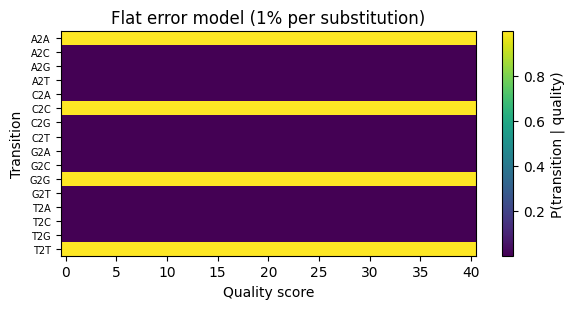

In [3]:
err = np.full((16, 41), 1e-3)
# self-transitions = 1 - sum(others)
for i in range(4):
    err[i*4 + i] = 1 - 3*1e-3

# Visualise the error matrix structure
fig, ax = plt.subplots(figsize=(6, 3.2))
im = ax.imshow(err, aspect='auto', cmap='viridis')
ax.set_yticks(range(16))
ax.set_yticklabels([f'{i}2{j}' for i in 'ACGT' for j in 'ACGT'], fontsize=7)
ax.set_xlabel('Quality score'); ax.set_ylabel('Transition')
ax.set_title('Flat error model (1% per substitution)')
plt.colorbar(im, ax=ax, label='P(transition | quality)'); plt.tight_layout()
plt.show()

## 3. Run DADA2 inference

`dada()` mirrors R DADA2's `dada()` and returns a dict of:

- `denoised` — `OrderedDict[asv_seq] -> abundance`
- `clustering` — list of per-cluster records (`birth_type`, `birth_pval`, `n0`, `nunq`, ...)
- `map` — for each input unique, the cluster index it was assigned to (-1 if not corrected)
- `trans` — observed (16, n_q) transition counts
- `err_in` / `err_out` — error matrices in/out (`err_out == err_in` when not selfConsist)


In [4]:
res = dada(drp, err=err, verbose=True)
print(f'\nInferred ASVs: {len(res["clustering"])}')


Inferred ASVs: 9


## 4. Inspect the inferred ASVs

In [5]:
import pandas as pd
clust = pd.DataFrame(res['clustering'])
clust['short_seq'] = clust['sequence'].str[:30] + '…'
clust[['short_seq', 'abundance', 'n0', 'nunq', 'birth_type', 'birth_pval']]

,short_seq,abundance,n0,nunq,birth_type,birth_pval
0,TACGGAGGATCCGAGCGTTATCCGGATTTA…,517,205,276,I,0.000000e+00
1,TACGGAGGATCCGAGCGTTATCCGGATTTA…,401,164,220,A,0.000000e+00
2,TACGGAGGATCCGAGCGTTATCCGGATTTA…,58,27,32,A,0.000000e+00
3,TACGTAGGGGGCAAGCGTTATCCGGATTTA…,47,17,29,A,0.000000e+00
4,TACGGAGGATCCGAGCGTTATCCGGATTTA…,63,12,40,A,0.000000e+00
5,TACGGAGGATCCGAGCGTTATCCGGATTTA…,147,57,90,A,3.050164e-267
6,TACGGAGGATGCGAGCGTTATCCGGATTTA…,9,4,6,A,2.518405e-183
7,TACGGAGGATCCGAGCGTTATCCGGATTTA…,76,31,46,A,9.787389e-50
8,TACGGAGGATCCGAGCGTTATCCGGATTTA…,13,3,11,A,1.962167e-43


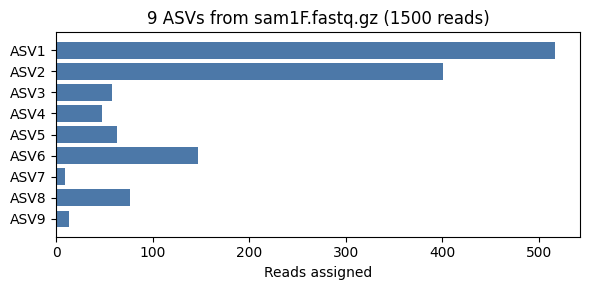

In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(range(len(clust)), clust['abundance'], color='#4c78a8')
ax.set_yticks(range(len(clust))); ax.set_yticklabels([f'ASV{i+1}' for i in range(len(clust))])
ax.set_xlabel('Reads assigned'); ax.invert_yaxis()
ax.set_title(f'{len(clust)} ASVs from sam1F.fastq.gz ({int(drp.abundances().sum())} reads)')
plt.tight_layout(); plt.show()

## 5. R-parity check

This same input + flat error matrix on R DADA2 1.34.0 returns the
**same number of ASVs**, the **same ASV sequences**, and the **same
abundances** — verified by `tests/test_r_parity.py`. The Python port
is bit-exact for this fixture.

```bash
$ pytest tests/test_r_parity.py -v
PASSED  test_derep_matches_r
PASSED  test_dada_cluster_count_matches_r
PASSED  test_dada_top_asv_sequence_matches_r
PASSED  test_dada_all_asv_sequences_present
PASSED  test_dada_abundances_match_r
```

For a side-by-side runtime comparison vs R DADA2 (Rscript
subprocess) on the same fixture, see
[`tutorial_vs_R.ipynb`](tutorial_vs_R.ipynb). v0.1 ships a
matrix-broadcast kmer-screen (~3.8x speedup over the naive
loop) and is numerically identical to R DADA2 on this fixture.
